## COSTO DE CAPITAL

Estimación del beta ascendente de GrupoTraxion a partir de comparables que cotizan en el sector.

- Indice: SP500 con ticker ^GSPC
- 3 años
- Frecuencia semanal
- Precios ajustados por dividendos

La fecha de valoración decidida en la bitacor es el 7 de agosto de 2026.

In [1]:
import pandas as pd
import yfinance as yf
from scipy import stats

INICIO = "2023-08-07"
FIN = "2026-08-07"
INDICE = "^GSPC"

In [2]:
mercado = yf.download(INDICE, start=INICIO, end=FIN, interval="1wk",
                      auto_adjust=True, progress=False)["Close"].squeeze()

print(f"Observaciones: {len(mercado)}")
print(f"Desde {mercado.index[0].date()} hasta {mercado.index[-1].date()}")
mercado.tail()

Observaciones: 157
Desde 2023-08-07 hasta 2026-08-03


Date
2026-07-06    7575.390137
2026-07-13    7457.689941
2026-07-20    7411.979980
2026-07-27    7489.720215
2026-08-03    7757.640137
Name: ^GSPC, dtype: float64

In [3]:
#retornos
ret_mercado = mercado.pct_change().dropna()

print(f"Observaciones: {len(ret_mercado)}")
print(f"Retorno semanal promedio: {ret_mercado.mean():.4%}")
print(f"Desviacion estandar semanal: {ret_mercado.std():.4%}")
ret_mercado.tail()

Observaciones: 156
Retorno semanal promedio: 0.3751%
Desviacion estandar semanal: 2.0154%


Date
2026-07-06    0.012314
2026-07-13   -0.015537
2026-07-20   -0.006129
2026-07-27    0.010488
2026-08-03    0.035772
Name: ^GSPC, dtype: float64

In [4]:
#primera regresion ODFL:Old Dominion Freight Line, primera comparable
odfl = yf.download("ODFL", start=INICIO, end=FIN, interval="1wk",
                   auto_adjust=True, progress=False)["Close"].squeeze()
ret_odfl = odfl.pct_change().dropna()

par = pd.concat([ret_odfl, ret_mercado], axis=1, join="inner").dropna()
par.columns = ["activo", "mercado"]

ajuste = stats.linregress(par["mercado"], par["activo"])

print(f"Observaciones : {len(par)}")
print(f"Beta          : {ajuste.slope:.3f}")
print(f"Error estandar: {ajuste.stderr:.3f}")
print(f"R2            : {ajuste.rvalue**2:.3f}")
print(f"Correlacion   : {ajuste.rvalue:.3f}")
print(f"Alfa semanal  : {ajuste.intercept:.4%}")

Observaciones : 156
Beta          : 1.004
Error estandar: 0.176
R2            : 0.175
Correlacion   : 0.418
Alfa semanal  : -0.2152%


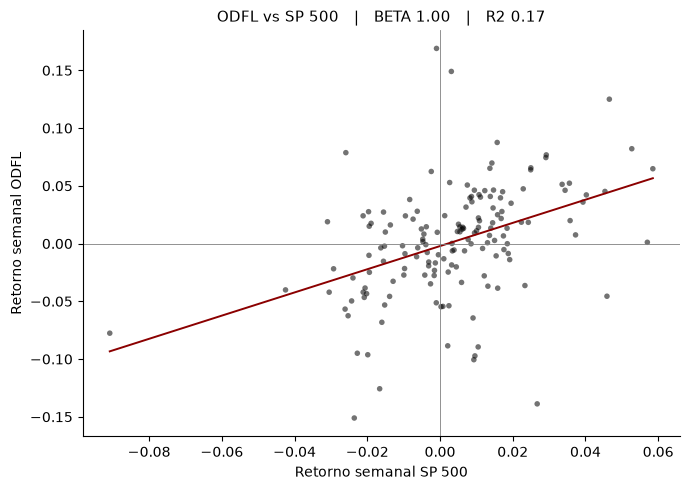

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(par["mercado"], par["activo"], s=16, alpha=0.55,
           color="black", edgecolors="none")

x = pd.Series([par["mercado"].min(), par["mercado"].max()])
ax.plot(x, ajuste.intercept + ajuste.slope * x, color="darkred", linewidth=1.4)

ax.axhline(0, color="gray", linewidth=0.6)
ax.axvline(0, color="gray", linewidth=0.6)
ax.set_xlabel("Retorno semanal SP 500")
ax.set_ylabel("Retorno semanal ODFL")
ax.set_title(f"ODFL vs SP 500   |   BETA {ajuste.slope:.2f}   |   R2 {ajuste.rvalue**2:.2f}",
             fontsize=11)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/regresion_individualODFL.png", dpi=150, bbox_inches="tight")
plt.show()
plt.show()

Prueba con comparable:

ODFL se usa como prueba antes de correr las veinte porque es la mas limpia del grupo. Se regresan los retornos semanales de la acción contra los del sp500, la pendiente de esta recta es el beta: 1.00

Como se puede obsaervar en el R2 el mercado explica el 17.5% de la variación de ODFL, el porcentaje restante es riesgo especifico de la empresa el cual es diversificable. Es un valor alto para el sector teniendo en cuenta que la muestra de Trucking de Damodaran promedia alrededor del 13%.



In [6]:
comparables = pd.read_csv("../data/interim/comparables.csv")
incluidas = comparables[comparables["incluida"] == "si"]

print(f"Comparables incluidas: {len(incluidas)}")
print(incluidas.groupby("segmento").size().to_string())
incluidas[["ticker", "nombre", "pais", "segmento"]]

Comparables incluidas: 20
segmento
carga        11
logistica     8
personas      1


,ticker,nombre,pais,segmento
0,ARCB,ArcBest Corporation,United States,carga
2,CVLG,Covenant Logistics Group,United States,carga
4,HTLD,Heartland Express,United States,carga
5,JBHT,J.B. Hunt Transport Services,United States,carga
6,KNX,Knight-Swift Transportation,United States,carga
7,LSTR,Landstar System,United States,logistica
8,MRTN,Marten Transport,United States,carga
9,ODFL,Old Dominion Freight Line,United States,carga
12,RXO,RXO Inc,United States,logistica
14,SAIA,Saia Inc,United States,carga


In [7]:
tickers_yahoo = {
    "NTG": "NTG.CO",
    "IDL": "IDL.PA",
    "KLS": "KLS.AX",
    "TFII": "TFII.TO",
}

def ticker_yahoo(t):
    """Traduce el ticker del listado de Damodaran al de Yahoo Finance"""
    return tickers_yahoo.get(t, t)

incluidas["ticker_yf"] = incluidas["ticker"].apply(ticker_yahoo)
incluidas[["ticker", "ticker_yf", "nombre", "segmento"]]

,ticker,ticker_yf,nombre,segmento
0,ARCB,ARCB,ArcBest Corporation,carga
2,CVLG,CVLG,Covenant Logistics Group,carga
4,HTLD,HTLD,Heartland Express,carga
5,JBHT,JBHT,J.B. Hunt Transport Services,carga
6,KNX,KNX,Knight-Swift Transportation,carga
7,LSTR,LSTR,Landstar System,logistica
8,MRTN,MRTN,Marten Transport,carga
9,ODFL,ODFL,Old Dominion Freight Line,carga
12,RXO,RXO,RXO Inc,logistica
14,SAIA,SAIA,Saia Inc,carga


In [8]:
def beta_regresion(ticker, ret_mercado, inicio, fin, frecuencia="1wk"):
    """Descarga precios, calcula retornos y los regresa contra el mercado.
    Devuelve beta, R2, correlacion, error estandar y observaciones"""
    precios = yf.download(ticker, start=inicio, end=fin, interval=frecuencia,
                          auto_adjust=True, progress=False)["Close"].squeeze()
    if precios.empty:
        raise ValueError(f"Sin precios para {ticker}")

    ret = precios.pct_change().dropna()

    par = pd.concat([ret, ret_mercado], axis=1, join="inner").dropna()
    par.columns = ["activo", "mercado"]

    if len(par) < 30:
        raise ValueError(f"{ticker}: solo {len(par)} observaciones")

    aj = stats.linregress(par["mercado"], par["activo"])

    return {
        "beta": aj.slope,
        "error_estandar": aj.stderr,
        "r2": aj.rvalue ** 2,
        "correlacion": aj.rvalue,
        "alfa_semanal": aj.intercept,
        "observaciones": len(par),
    }

In [9]:
resultados = []

for _, fila in incluidas.iterrows():
    r = beta_regresion(fila["ticker_yf"], ret_mercado, INICIO, FIN)
    r["ticker"] = fila["ticker"]
    r["nombre"] = fila["nombre"]
    r["segmento"] = fila["segmento"]
    r["pct_activos"] = fila["pct_ingresos_negocio"]
    resultados.append(r)

betas = pd.DataFrame(resultados)
betas[["ticker", "segmento", "beta", "error_estandar", "r2", "observaciones"]].round(3)

,ticker,segmento,beta,error_estandar,r2,observaciones
0,ARCB,carga,1.346,0.237,0.174,156
1,CVLG,carga,1.063,0.194,0.163,156
2,HTLD,carga,0.846,0.182,0.124,156
3,JBHT,carga,0.950,0.148,0.211,156
4,KNX,carga,1.021,0.156,0.217,156
5,LSTR,logistica,0.856,0.140,0.194,156
6,MRTN,carga,0.791,0.146,0.160,156
7,ODFL,carga,1.004,0.176,0.175,156
8,RXO,logistica,1.642,0.308,0.156,156
9,SAIA,carga,1.267,0.259,0.135,156


In [10]:
betas[betas["segmento"] != "personas"].groupby("segmento")[["beta", "r2"]].agg(["mean", "median", "count"]).round(3)

beta                  r2             
            mean median count   mean median count
segmento                                         
carga      0.960  0.950    11  0.157  0.160    11
logistica  1.037  0.926     8  0.147  0.147     8

El R2 promedio de 15.2% supera el que reporta Damodaran alrededor de 13% para la muestra de trucking EEUU. La diferencia puede significar que los datos semanales contra el SP500 miden mejor que los mensuales contra indices locales.

Error estandar promedio de 0.19.

Kelsian queda fuera de los promedios. 

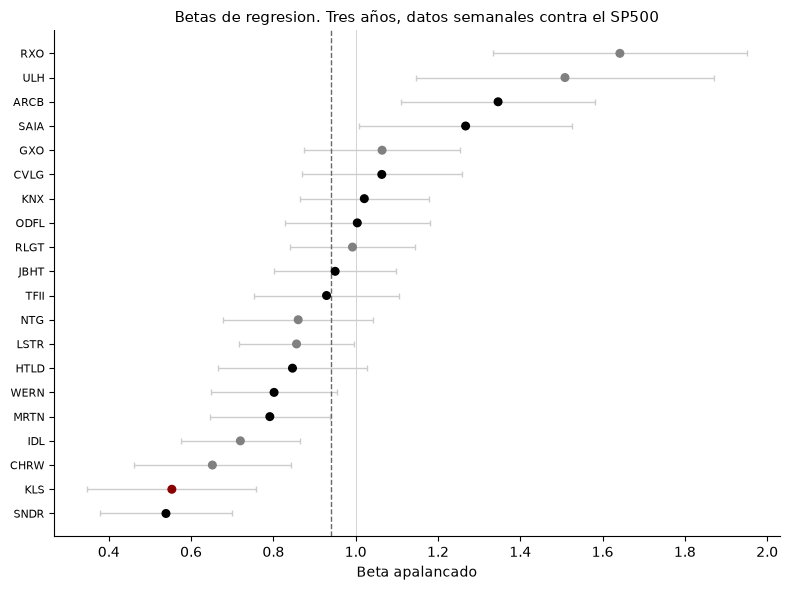

In [11]:
b = betas.sort_values("beta").reset_index(drop=True)
colores = {"carga": "black", "logistica": "gray", "personas": "darkred"}

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(b["beta"], b.index, xerr=b["error_estandar"],
            fmt="none", ecolor="#cccccc", elinewidth=1, capsize=2)
ax.scatter(b["beta"], b.index, s=30, zorder=3,
           color=[colores[s] for s in b["segmento"]])

ax.axvline(b["beta"].median(), color="dimgray", linewidth=1, linestyle="--")
ax.axvline(1.0, color="#cccccc", linewidth=0.6)

ax.set_yticks(b.index)
ax.set_yticklabels(b["ticker"], fontsize=8)
ax.set_xlabel("Beta apalancado")
ax.set_title("Betas de regresion. Tres años, datos semanales contra el SP500",
             fontsize=11)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/betas_comparables.png", dpi=150, bbox_inches="tight")
plt.show()

Cada punto es el beta estimado de una comparable y la barra gris su error estandar. Kelsian aparece en el extramo bajo y se pone de otro color (rojo oscuro) ya que justamente se decidio que no entra en el calculo por ser la unica comparable de movilidad de personas y en la tabla anterior se observo que es el R2 mas bajo del grupo: 0.04. Carga tiene color negro y logistica color gris.

In [12]:
#regresion de traxion, unicamente contraste: no entra en el modelo
traxion = beta_regresion("TRAXIONA.MX", ret_mercado, INICIO, FIN)
traxion

{'beta': np.float64(0.5943751400719487),
 'error_estandar': np.float64(0.18218964122405165),
 'r2': np.float64(0.0646442653723743),
 'correlacion': np.float64(0.25425236551972197),
 'alfa_semanal': np.float64(-0.006831895188871379),
 'observaciones': 156}

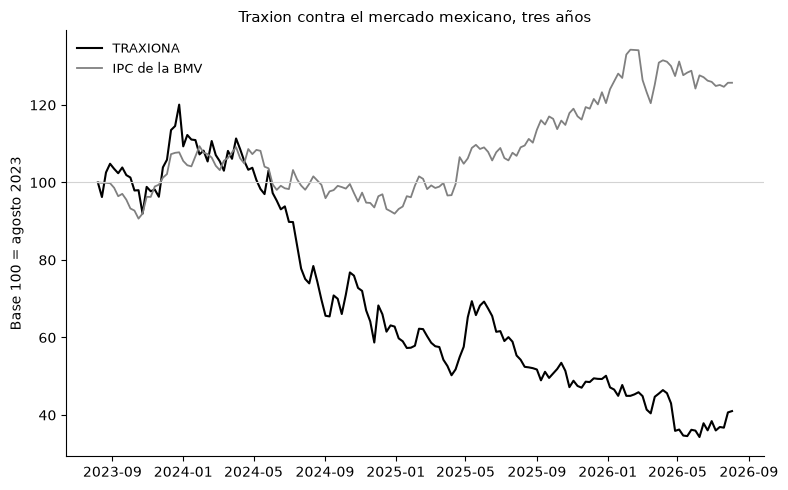

Traxion: -59.0%
IPC    : +25.7%


In [ ]:
traxion_px = yf.download("TRAXIONA.MX", start=INICIO, end=FIN, interval="1wk",
                         auto_adjust=True, progress=False)["Close"].squeeze()
ipc_px = yf.download("^MXX", start=INICIO, end=FIN, interval="1wk",
                     auto_adjust=True, progress=False)["Close"].squeeze()

base = pd.concat([traxion_px, ipc_px], axis=1, join="inner").dropna()
base.columns = ["Traxion", "IPC"]
base = base / base.iloc[0] * 100

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(base.index, base["Traxion"], color="black", linewidth=1.5, label="TRAXIONA")
ax.plot(base.index, base["IPC"], color="gray", linewidth=1.3, label="IPC de la BMV")
ax.axhline(100, color="lightgray", linewidth=0.8)

ax.set_ylabel("Base 100 = agosto 2023")
ax.set_title("Traxion contra el mercado mexicano, tres años", fontsize=11)
ax.legend(frameon=False, fontsize=9)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/traxion_vs_mercado.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Traxion: {base['Traxion'].iloc[-1]-100:+.1f}%")
print(f"IPC    : {base['IPC'].iloc[-1]-100:+.1f}%")

In [14]:
ipc = yf.download("^MXX", start=INICIO, end=FIN, interval="1wk",
                  auto_adjust=True, progress=False)["Close"].squeeze()
ret_ipc = ipc.pct_change().dropna()

traxion_local = beta_regresion("TRAXIONA.MX", ret_ipc, INICIO, FIN)
traxion_local

{'beta': np.float64(0.7410468046647817),
 'error_estandar': np.float64(0.1749232557153231),
 'r2': np.float64(0.10437611336649019),
 'correlacion': np.float64(0.32307292267612),
 'alfa_semanal': np.float64(-0.005845296878919217),
 'observaciones': 156}

Con la regresión de Traxion se confirma la importancia el enfoque de Damodaran de betas ascendentes y por que el beta de regresión individual es inservible. El intervalo de confianza contra el SP500 es demasiado amplio y el costo del patrimonio variaría demasiado. No es posible valorar bien.

El r2 de 6.5% es la mitad del promedio de los 20 comparables (alrededor de 15%). Sube contra el indice local pero poco. El r2 no salta a niveles como de los de las comparables estadounidenses.

**DESAPALANCAR**

Los betas obtenidos son betas apalancados, reflejan el riesgo del negocio + el riesgo financiero de cada empresa.

Para desapalancar: 

$$
\beta_U = \frac{\beta_L}{1 + (1-t)\frac{D}{E}}
$$

Despues se promedian y se vuelve a apalancar con el D/E de Traxion.

Importante declarar una limitación. La deuda total de Yahoo (de donde se obtendran los datos de deuda de cada empresa) probablemente incluya o excluya arrendamientos de forma inconsistente. Es el mismo problema encontrado con Traxion, donde la empresa reportaba una deuda y el criterio economico y de Damodaran daba otra más grande incluyendo arrendamientos IFRS16. Se usara Yahoo con esta limitación pero con una verificación: se comparara el D/E promedio que salga contra el 21.5% implicito de la muestra de trucking EEUU de Damodaran. 

Dicho 21.5% sale de docs/img/damodaran_beta_trucking_us.png, con 0.87 y 1.01 y una tasa marginal de 25%:

$$
\frac{D}{E} = \frac{\frac{1.01}{0.87} - 1}{1 - 0.25} = 21.5\%
$$

In [15]:
def datos_balance(ticker):
    """Obtiene deuda total, capitalizacion de mercado y caja de Yahoo Finance"""
    info = yf.Ticker(ticker).info
    return {
        "deuda": info.get("totalDebt"),
        "cap_mercado": info.get("marketCap"),
        "caja": info.get("totalCash"),
    }

balance = []
for _, fila in incluidas.iterrows():
    d = datos_balance(fila["ticker_yf"])
    d["ticker"] = fila["ticker"]
    balance.append(d)

balance = pd.DataFrame(balance)
balance

,deuda,cap_mercado,caja,ticker
0,459759008,2905005568,168431008,ARCB
1,324433984,872741760,2615000,CVLG
2,146403008,918711360,62385000,HTLD
3,1403336960,22232481792,4162000,JBHT
4,2685164032,10706089984,186114000,KNX
5,139104992,5740091392,347702016,LSTR
6,358000,1117131648,103980000,MRTN
7,19997000,36261351424,283939008,ODFL
8,728000000,3146790400,15000000,RXO
9,269191008,9139652608,84014000,SAIA


In [16]:
balance["de"] = balance["deuda"] / balance["cap_mercado"]
balance["caja_ev"] = balance["caja"] / (balance["cap_mercado"] + balance["deuda"] - balance["caja"])

comp = balance.merge(betas[["ticker", "segmento"]], on="ticker")
sin_kelsian = comp[comp["segmento"] != "personas"]

print(f"D/E mediana: {sin_kelsian['de'].median():.1%}")
print(f"D/E media:   {sin_kelsian['de'].mean():.1%}")

comp.sort_values("de", ascending=False)[["ticker", "segmento", "de", "caja_ev"]].round(3)

D/E mediana: 18.8%
D/E media:   34.1%


,ticker,segmento,de,caja_ev
13,ULH,logistica,1.688,0.015
14,GXO,logistica,1.156,0.072
19,KLS,personas,0.964,0.089
18,IDL,logistica,0.876,0.103
17,NTG,logistica,0.459,0.049
11,WERN,carga,0.440,0.019
1,CVLG,carga,0.372,0.002
4,KNX,carga,0.251,0.014
8,RXO,logistica,0.231,0.004
16,TFII,carga,0.211,0.012


Mediana del D/E de 19%, contra la referencia aprox de 21.5%: los datos si son razonables. 
Se usa mediana pues la distribución esta sesgada por ULH y GXO. Argumento para usar mediana en el promedio de betas desapalancados.

Se verifico la definición de deuda en Yahoo Finance.
se contrasto esta deuda de GXO contra su balance al 31/12/2025

Los arrendamientos son el 48% de la deuda ajustada. **Yahoo incluye las
obligaciones por arrendamiento en su definición de deuda**, de modo que los
datos de las comparables son consistentes con el criterio adoptado para
Traxión en el Módulo 1, donde se reincorporaron los arrendamientos IFRS 16
Fuente: sec.gov 10k annual report

**TASAS MARGINALES PARA DESAPALANCAR**

Se obtiene countrytaxrates.xls de DamodaranOnline Data: Corporate Tax Rates by Country, actualizado en enero de 2026, y se guarda en dataraw.
Las tasas marginales obtenidas de esta fuente son:

| País | Tasa | Comparables |
|---|---|---|
| Estados Unidos | 25.63% | 15 |
| Canadá | 26.14% | TFII |
| Dinamarca | 22.00% | NTG |
| Francia | 25.83% | IDL |
| Australia | 30.00% | KLS |
| México | 30.00% | Traxión |



In [17]:
comp = comp.merge(incluidas[["ticker", "pais"]], on="ticker")

tasas = {
    "United States": 0.2563,
    "Canada": 0.2614,
    "Denmark": 0.2200,
    "France": 0.2583,
    "Australia": 0.3000,
}

comp["tasa"] = comp["pais"].map(tasas)
comp[["ticker", "pais", "tasa"]]

,ticker,pais,tasa
0,ARCB,United States,0.2563
1,CVLG,United States,0.2563
2,HTLD,United States,0.2563
3,JBHT,United States,0.2563
4,KNX,United States,0.2563
5,LSTR,United States,0.2563
6,MRTN,United States,0.2563
7,ODFL,United States,0.2563
8,RXO,United States,0.2563
9,SAIA,United States,0.2563


In [18]:
#desapalancar
comp = comp.merge(betas[["ticker", "beta"]], on="ticker")

comp["beta_u"] = comp["beta"] / (1 + (1 - comp["tasa"]) * comp["de"])
comp["beta_u_corregido"] = comp["beta_u"] / (1 - comp["caja_ev"])

comp[["ticker", "segmento", "beta", "de", "beta_u", "caja_ev", "beta_u_corregido"]].round(3)

,ticker,segmento,beta,de,beta_u,caja_ev,beta_u_corregido
0,ARCB,carga,1.346,0.158,1.204,0.053,1.271
1,CVLG,carga,1.063,0.372,0.833,0.002,0.835
2,HTLD,carga,0.846,0.159,0.757,0.062,0.807
3,JBHT,carga,0.950,0.063,0.907,0.000,0.908
4,KNX,carga,1.021,0.251,0.860,0.014,0.873
5,LSTR,logistica,0.856,0.024,0.841,0.063,0.898
6,MRTN,carga,0.791,0.000,0.791,0.103,0.882
7,ODFL,carga,1.004,0.001,1.003,0.008,1.011
8,RXO,logistica,1.642,0.231,1.401,0.004,1.406
9,SAIA,carga,1.267,0.029,1.240,0.009,1.251


### BETAS DESAPALANCADOS

Se aplican dos ajustes de la metodologia de Aswath Damodaran. El primero quita el efecto de la estructura de capital de cada empresa de forma:

$$
\beta_U = \frac{\beta_L}{1 + (1-t) \times \frac{D}{E}}
$$

El segundo corrgige por caja. Caja tiene beta cero, de forma que un balance con demasiado efectivo baja el beta sin que el negocio sea necesariamente menos riesgoso:

$$
\beta_{U,\text{corregido}} =
\frac{\beta_U}{1 - \frac{\text{Caja}}{\text{Valor de la firma}}}
$$

| Grupo | n | Media | Mediana |
|---|---|---|---|
| Carga | 11 | 0.895 | 0.873 |
| Logística | 8 | 0.794 | 0.677 |
| Conjunto | 19 | 0.853 | 0.839 |

La mediana de carga coincide casi exactamente con el beta desapalancado que Damodaran reporta para la muestra de trucking de EEUU 0.87. Estimado con otra frecuencia y metodo. La coincidencia por dos caminos distintos es la mejor verificacion de que esta bien.

Logistica queda por debajo de carga, y en losgistica la media supera a la mediana por mas de un punto por la influencia de RXO (1.43). Se usará la mediana.

ULH y GXO renian los betas apalancados más altos y quedan entre los más bajos al desapalancar. Su D/E explicaba casi todo el beta. 

La relación entre beta desapalancado y proporción de activos propios en el
grupo de carga es positiva pero débil (correlación de 0.26 sobre once
observaciones). No es concluyente: ArcBest, con 68% de activos propios,
tiene el segundo beta más alto, mientras Schneider, con 75%, tiene el más
bajo. La hipótesis del apalancamiento operativo no queda confirmada ni
refutada con esta muestra.

**Para ponderación**


In [19]:
comp = comp.merge(incluidas[["ticker", "ticker_yf"]], on="ticker")
def ventas_yahoo(ticker):
    return yf.Ticker(ticker).info.get("totalRevenue")

comp["ventas"] = comp["ticker_yf"].apply(ventas_yahoo)
comp["ev"] = comp["cap_mercado"] + comp["deuda"] - comp["caja"]
comp["ev_ventas"] = comp["ev"] / comp["ventas"]

comp[["ticker", "segmento", "ev_ventas"]].round(2)

,ticker,segmento,ev_ventas
0,ARCB,carga,0.76
1,CVLG,carga,0.97
2,HTLD,carga,1.36
3,JBHT,carga,1.86
4,KNX,carga,1.71
5,LSTR,logistica,1.11
6,MRTN,carga,1.18
7,ODFL,carga,6.43
8,RXO,logistica,0.63
9,SAIA,carga,2.75


In [20]:
comp.groupby("segmento")["ev_ventas"].median().round(2)

segmento
carga        1.36
logistica    0.82
personas     0.82
Name: ev_ventas, dtype: float64

Los múltiplos medianos difieren de forma sistemática entre segmentos: carga 1.46x, personas 0.95x, logística 0.82x.

Aplicando cada múltiplo a los ingresos del segmento correspondiente se
estima su valor y de ahí los pesos. Logística pierde 8.4 puntos respecto de
la ponderación por ingresos: aporta la mitad de las ventas pero dos quintos
del valor, coherente con sus márgenes de 2-3%.

El beta ponderado da 0.776 por ingresos y 0.793 por valor. Se adopta el
segundo.

**REAPALANCAR**

$$\beta_L = \beta_U \times \left[1 + (1 - t)\frac{D}{E}\right]$$

El patrimonio debe ser a valor de mercado, no contable:
- precio de TRAXIONA a la fecha de valoracion
- acciones en circulación


In [21]:
precio = yf.download("TRAXIONA.MX", start="2026-08-01", end="2026-08-10",
                     interval="1d", auto_adjust=True, progress=False)["Close"]
precio

Ticker,TRAXIONA.MX
Date,
2026-08-03,11.90
2026-08-04,11.88
2026-08-05,11.70
2026-08-06,11.64
2026-08-07,11.89


In [22]:
acciones = yf.Ticker("TRAXIONA.MX").info.get("sharesOutstanding")
acciones

555980425

Deuda de Traxion jun-2026: 15935.7

Patrimonio a valor de mercado: 11.89*555980425 = 6610.6

In [23]:
precio = 11.89
deuda = 15935.7
tasa_mx = 0.30
beta_u = 0.793

cap_mercado = precio * acciones / 1e6
de_traxion = deuda / cap_mercado
beta_l = beta_u * (1 + (1 - tasa_mx) * de_traxion)

print(f"Capitalizacion de mercado : {cap_mercado:,.1f} millones MXN")
print(f"D/E                       : {de_traxion:.1%}")
print(f"Deuda / (Deuda + Patrimonio): {deuda/(deuda+cap_mercado):.1%}")
print(f"Beta reapalancado         : {beta_l:.3f}")

Capitalizacion de mercado : 6,610.6 millones MXN
D/E                       : 241.1%
Deuda / (Deuda + Patrimonio): 70.7%
Beta reapalancado         : 2.131


### Beta reapalancado


$$\beta_L = \beta_U \times \left[1 + (1 - t)\frac{D}{E}\right]$$

$$\beta_L = 0.793 \times \left[1 + 0.70 \times 2.411\right] = 2.131$$


El D/E de 241% domina el resultado. 
70.7% de estructura de capital, cuando la mediana de las comparables es del 19%.

Traxion esta muy por encima. La deuda creción con la adquisición de Solistica, y el patrimonio de mercado se ha contraido por caidas del precio de la acción. 
*Adevertencia sobre el D/E utilizado** Se emplea el ratio actual a precios de mercado. La administracion anuncncio un plan para reducir el apalancamiento al cierre del año. queda pendiente decidir si se usa el D/E actual, uno objetivo, o el que resulte del cronograma de estructura optima.

$$Ke_{USD} = R_f + \beta_L \times ERP = 4.43\% + 2.131 \times 6.82\% = 18.96\%$$

$$Ke_{\text{MXN}} = \frac{(1 + 18.96\%)(1 + 3.75\%)}{(1 + 2.25\%)} - 1 = 20.71\%$$

Conversión a pesos con inflaciones esperadas a mediano plazo.

## COSTO DE DEUDA

$$K_d = R_f + \text{spread país} + \text{spread empresa}$$

$$K_d después de impuestos = K_d \times (1 - t)$$

El spread de la empresa no está disponible directamente porque el rating que se busca es el de la deuda de Traxión medido en escala internacional comparable. Se estima con el índice de cobertura de intereses.

In [24]:
rf = 0.0443
spread_mexico = 0.0152
infl_mxn = 0.0375
infl_usd = 0.0225
tasa_mx = 0.30

ebit_base = 2456.3
gasto_intereses = 1753.8
deuda = 15935.7

kd_efectivo_mxn = gasto_intereses / deuda
kd_efectivo_usd = (1 + kd_efectivo_mxn) * (1 + infl_usd) / (1 + infl_mxn) - 1
gasto_intereses_usd = deuda * kd_efectivo_usd

cobertura = ebit_base / gasto_intereses_usd

print(f"kd efectivo en pesos           : {kd_efectivo_mxn:.2%}")
print(f"kd efectivo equivalente en USD : {kd_efectivo_usd:.2%}")
print(f"Gasto de intereses equivalente : {gasto_intereses_usd:,.1f}")
print(f"Cobertura de intereses         : {cobertura:.2f}x")
print(f"Cobertura con intereses en MXN : {ebit_base/gasto_intereses:.2f}x")

kd efectivo en pesos           : 11.01%
kd efectivo equivalente en USD : 9.40%
Gasto de intereses equivalente : 1,498.0
Cobertura de intereses         : 1.64x
Cobertura con intereses en MXN : 1.40x


### Índice de cobertura de intereses

$$\text{Cobertura de intereses} = \frac{EBIT}{\text{Gasto por intereses}} = \frac{2{,}456.3}{1{,}753.8} = 1.40\times$$


**Se usa el EBIT del año base, no el de los últimos doce meses.** 


**El gasto por intereses incluye el componente de arrendamientos IFRS 16.**

In [25]:
tabla_ratings = [
    (-100000, 0.499999, "D2/D",     0.1900),
    (0.5,     0.799999, "C2/C",     0.1600),
    (0.8,     1.249999, "Ca2/CC",   0.1261),
    (1.25,    1.499999, "Caa/CCC",  0.0885),
    (1.5,     1.999999, "B3/B-",    0.0509),
    (2.0,     2.499999, "B2/B",     0.0321),
    (2.5,     2.999999, "B1/B+",    0.0275),
    (3.0,     3.499999, "Ba2/BB",   0.0184),
    (3.5,     3.999999, "Ba1/BB+",  0.0138),
    (4.0,     4.499999, "Baa2/BBB", 0.0111),
    (4.5,     5.999999, "A3/A-",    0.0089),
    (6.0,     7.499999, "A2/A",     0.0078),
    (7.5,     9.499999, "A1/A+",    0.0070),
    (9.5,    12.499999, "Aa2/AA",   0.0055),
    (12.5,  100000,     "Aaa/AAA",  0.0040),
]

def rating_sintetico(cobertura, tabla=tabla_ratings):
    """Traduce un indice de cobertura de intereses a rating y spread de default"""
    for minimo, maximo, rating, spread in tabla:
        if minimo <= cobertura <= maximo:
            return rating, spread
    raise ValueError(f"Cobertura fuera de rango: {cobertura}")

rating, spread_empresa = rating_sintetico(cobertura)
print(f"Rating sintetico: {rating}")
print(f"Spread de default: {spread_empresa:.2%}")

Rating sintetico: B3/B-
Spread de default: 5.09%


**La cobertura debe calcularse en la misma moneda en que está calibrada la
tabla de ratings.** Damodaran construyó esa tabla con empresas
estadounidenses que se endeudan en dólares. El gasto de intereses de
Traxión está en pesos y por tanto incorpora la prima inflacionaria
mexicana: a igual apalancamiento real, una empresa mexicana muestra menor
cobertura simplemente porque sus tasas nominales son más altas.

Usar la cobertura en pesos y después convertir el spread resultante a pesos
con Fisher cobra el diferencial de inflación dos veces.

Se convierte el gasto de intereses a su equivalente en dólares antes de
buscar el rating:

    kd efectivo en pesos = 1,753.8 / 15,935.7 = 11.01%
    kd equivalente en dólares = (1.1101 × 1.0225 / 1.0375) − 1 = 9.40%
    Gasto de intereses equivalente = 15,935.7 × 9.40% = 1,498.0
    Cobertura = 2,456.3 / 1,498.0 = 1.64x

Con el gasto en pesos la cobertura sería 1.40x y el rating caería a
Caa/CCC con spread de 8.85%. La corrección de moneda mueve el rating a
B3/B− con spread de 5.09%, y el WACC tambien cambia.

Se obiene ratings sinteticos de Data de Damodaran y se añade a data raw como ratings.xls

Se uso la tabla de empresas pequeñas y riesgosas, no la de grandes. Traxion capitaliza 6610 millones de pesos, muy por debajo del umbral de 5000 millones de dolares.

In [26]:
kd_usd = rf + spread_mexico + spread_empresa
kd_mxn = (1 + kd_usd) * (1 + infl_mxn) / (1 + infl_usd) - 1
kd_despues_impuestos = kd_mxn * (1 - tasa_mx)

print(f"kd en dolares            : {kd_usd:.2%}")
print(f"kd en pesos              : {kd_mxn:.2%}")
print(f"kd despues de impuestos  : {kd_despues_impuestos:.2%}")

kd en dolares            : 11.04%
kd en pesos              : 12.67%
kd despues de impuestos  : 8.87%


$$K_d^{USD} = R_f + CRP + s_{\text{empresa}} = 4.43\% + 1.52\% + 5.09\% = 11.04\%$$

$$K_d^{MXN} = \frac{(1 + 11.04\%)(1 + 3.75\%)}{(1 + 2.25\%)} - 1 = 12.67\%$$

$$K_d^{\text{despues.i.}} = 12.67\% \times (1 - 30\%) = 8.87\%$$

### Contraste con la calificación real

| | |
|---|---|
| Fitch, escala nacional mexicana (29-may-2026) | **A+(mex)**, perspectiva estable |
| Rating sintético, tabla de empresas pequeñas | **B3/B−** |

**Las escalas no son comparables directamente.** La escala nacional mide
riesgo relativo dentro de México: su techo es el soberano, de modo que el
mejor emisor mexicano recibe AAA(mex) aunque México tenga Baa2 en escala
internacional. El rating sintético, en cambio, está en escala
internacional, porque la tabla de Damodaran se construyó con bonos
corporativos estadounidenses.

Un A+(mex) equivale aproximadamente a un rango entre BB y BBB− en escala
internacional. Frente a un sintético de B3/B−, la brecha real es de dos o
tres escalones.

## WACC

$$WACC = K_e \times \frac{E}{D + E} + K_d(1 - t) \times \frac{D}{D + E}$$

In [27]:
erp_total = 0.0682

ke_usd = rf + beta_l * erp_total
ke_mxn = (1 + ke_usd) * (1 + infl_mxn) / (1 + infl_usd) - 1

print(f"Ke en dolares : {ke_usd:.2%}")
print(f"Ke en pesos   : {ke_mxn:.2%}")

deuda = 15935.7
patrimonio = cap_mercado

w_deuda = deuda / (deuda + patrimonio)
w_patrimonio = patrimonio / (deuda + patrimonio)

wacc = ke_mxn * w_patrimonio + kd_despues_impuestos * w_deuda

print(f"Peso del patrimonio : {w_patrimonio:.1%}")
print(f"Peso de la deuda    : {w_deuda:.1%}")
print(f"WACC (MXN)          : {wacc:.2%}")

Ke en dolares : 18.96%
Ke en pesos   : 20.71%
Peso del patrimonio : 29.3%
Peso de la deuda    : 70.7%
WACC (MXN)          : 12.34%


## ROC

In [28]:
import sys
sys.path.append("..")
from src.datos import capital_invertido, roc
patrimonio_contable = 14260.9
efectivo = 1383.0
goodwill = 5297.3
intangibles = 2919.9

capital = capital_invertido(deuda, patrimonio_contable, efectivo)
capital_sin_gw = capital - goodwill
capital_operativo = capital - goodwill - intangibles

print(f"Capital invertido              : {capital:,.1f}   ROC {roc(ebit_base, capital, tasa_mx):.2%}")
print(f"Sin credito mercantil          : {capital_sin_gw:,.1f}   ROC {roc(ebit_base, capital_sin_gw, tasa_mx):.2%}")
print(f"Sin credito mercantil ni intang: {capital_operativo:,.1f}   ROC {roc(ebit_base, capital_operativo, tasa_mx):.2%}")
print(f"WACC                           : {wacc:.2%}")

Capital invertido              : 28,813.6   ROC 5.97%
Sin credito mercantil          : 23,516.3   ROC 7.31%
Sin credito mercantil ni intang: 20,596.4   ROC 8.35%
WACC                           : 12.34%


### Retorno sobre el capital contra costo de capital

| Base de capital | Capital | ROC |
|---|---|---|
| Total | 28,813.6 | 5.97% |
| Sin crédito mercantil | 23,516.3 | 7.31% |
| Sin crédito mercantil ni intangibles | 20,596.4 | 8.35% |

Separar el crédito mercantil distingue dos diagnósticos distintos. El ROC
sobre capital total mide si la empresa, incluyendo lo que pagó por sus
adquisiciones, genera retorno suficiente. El ROC sobre capital operativo
mide si el negocio rinde.

Con 8.35% sobre capital operativo contra 5.97% sobre capital total, buena
parte de la brecha viene del precio pagado en adquisiciones y no de la
operación. Traxión tiene 5,297 de crédito mercantil y 2,920 de intangibles,
28.5% del capital invertido.

**En ninguna de las tres bases el ROC alcanza el WACC de 12.34%.**

El capital se mide al cierre de junio de 2026. Se verificó contra el
capital de apertura (diciembre 2025, 28,863.6) y la diferencia es
inmaterial: la adquisición de Solistica se cerró en julio de 2025, de modo
que ya estaba incorporada en ambos balances.

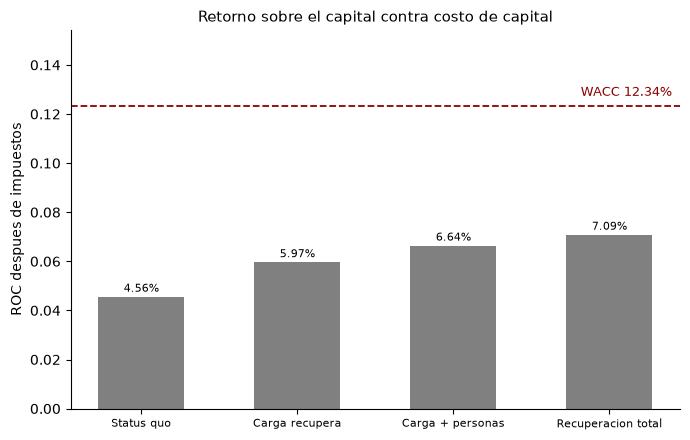

In [29]:
escenarios = {"Status quo": 0.0493, "Carga recupera": 0.0645,
              "Carga + personas": 0.0718, "Recuperacion total": 0.0766}
rocs = {k: 38082.2 * m * 0.70 / capital for k, m in escenarios.items()}

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(rocs.keys(), rocs.values(), color="gray", width=0.55)
ax.axhline(wacc, color="darkred", linewidth=1.3, linestyle="--")
ax.text(3.4, wacc + 0.004, f"WACC {wacc:.2%}", color="darkred",
        fontsize=9, ha="right")

for i, (k, v) in enumerate(rocs.items()):
    ax.text(i, v + 0.002, f"{v:.2%}", ha="center", fontsize=8)

ax.set_ylim(0, wacc * 1.25)
ax.set_ylabel("ROC despues de impuestos")
ax.set_title("Retorno sobre el capital contra costo de capital", fontsize=11)
ax.tick_params(axis="x", labelsize=8)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/roc_vs_wacc.png", dpi=150, bbox_inches="tight")
plt.show()

Ninguno de los cuatro escenarios de margen evaluados anteriormente lleva el ROC hasta el costo de capital. Incluso con recuperación total de los
tres segmentos a sus márgenes de hace un año, el retorno queda en 7.09% contra un WACC de 12.34%.